# H-005 · Window screens (OLS / ADF / entry z / z)

Sequential screens for OLS lookback, ADF window, entry z and fixed z-window, under **frozen
`BREAK_STAR` (H-003) and `BOOK_STAR` (H-004)**. Formerly Part B of H-003.

**Why this runs after H-004.** Fitting these windows on the frozen book and then handing them to
both arms would tune them on one architecture and bias the H-004 bake-off toward `freeze`. The
rotating arm would be competing with windows optimised for its opponent.

Each stage freezes one STAR before the next; these are sequential screens, **not** a joint grid.
Day-unit grids, session-scaled on 1h by `lookbacks_for_bar`.

STARs frozen here: `OLS_WINDOW_STAR`, `ADF_WINDOW_STAR`, `ENTRY_Z_STAR`, `Z_WINDOW_STAR`.

If `BOOK_STAR = rotate`, the discovery lookback `L` (pre-registered at 252 for H-004) may be
screened here and nowhere earlier.

Metrics: fold-val Sharpe, max DD, corr to S1. Rank on net Sharpe and read correlation beside it —
**a negative correlation to S1 beats a low positive one**.


## 0. Imports & Config


In [ ]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    arm_selection_table,
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DAY_OLS_WINDOW,
    DAY_Z_WINDOW,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    frozen_pairs_for_universe,
    load_s1_weekly,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_ols_hedge,
    split_is_oos,
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)

# Universe comes from H-001. The book is the ranked frozen book (caps 6 / 2) written by
# H-001; PAIRS_STAR is only populated once BOOK_STAR = freeze in H-004.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))

# Sequential day-unit grids; lookbacks_for_bar session-scales these on 1h.
OLS_DAY_GRID = (504, 252, 126, 63)  # 2y / 1y / 6m / quarterly
ADF_DAY_GRID = (504, 252, 126, 63)
ENTRY_Z_GRID = (1.5, 2.0, 2.5)
Z_DAY_GRID = (40, 60, 90)

print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)
print("n_variants sequential", len(OLS_DAY_GRID), "+", len(ADF_DAY_GRID), "+", len(ENTRY_Z_GRID), "+", len(Z_DAY_GRID))


stack keys: ['BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'UNIVERSE_STAR']
UNIVERSE E PAIRS ['CCI|AMT', 'SBAC|CCI', 'SBRA|VTR', 'NNN|O', 'NNN|WPC', 'PLD|TRNO']
n_variants sequential 4 + 4 + 3 + 3


## 1. Load frozen panel under `BREAK_STAR` / `BOOK_STAR`

Panel is rebuilt on default day windows so every screen starts from the same baseline.


**Book under `BOOK_STAR`.** `BOOK_STAR = freeze` scores the screens on the frozen ranked
book directly. `BOOK_STAR = rotate` scores them on the rotating book: load the quarterly
selections with `backtest.s2_coint.rotation.build_active_schedule` (or the saved
`s2_rebalance_{letter}_1d.csv`), turn them into entry masks with `schedule_to_masks`, and
score via `simulate_rotating_book` so demotion and orientation locks stay in force. The
window grids themselves are identical either way.


In [4]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
require_star("BOOK_STAR", stack.get("BOOK_STAR"))
BAR = str(stack["BAR_STAR"])
BOOK = str(stack["BOOK_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb0 = lookbacks_for_bar(BAR)
# Rebuild with default day windows so every screen starts from the same baseline.
train = overlay_ols_hedge(
    train,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 32407 OOS rows 7038


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1994-10-18,NNN|O,NNN,O,12.250,12.250,12.125,12.250,7.751938,7.812500,7.630814,7.751938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1994-10-19,NNN|O,NNN,O,12.250,12.375,12.125,12.375,7.812500,8.478682,7.812500,8.418120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1994-10-20,NNN|O,NNN,O,12.250,12.500,12.250,12.375,8.539244,8.781492,8.478682,8.478682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1994-10-21,NNN|O,NNN,O,12.375,12.375,12.250,12.250,8.478682,8.539244,8.296996,8.357558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1994-10-24,NNN|O,NNN,O,12.250,12.375,12.250,12.375,8.357558,8.539244,8.175872,8.175872,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Walk-forward folds


In [5]:
panel = is_panel.copy()
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1994-10-18,2001-07-23,1707,2001-07-24,2001-07-30,2001-07-31,2008-05-23,1713
1,2,1994-10-18,2008-05-16,3420,2008-05-19,2008-05-23,2008-05-27,2015-03-16,1713
2,3,1994-10-18,2015-03-09,5133,2015-03-10,2015-03-16,2015-03-17,2021-12-31,1713


## 3. Sequential screens under frozen `BREAK_STAR`

Each stage freezes one STAR before the next. Boxplots of Sharpe / max DD / corr to S1;
cost commentary is manual from trade counts when useful.


### 3.1 OLS lookback screen → `OLS_WINDOW_STAR`


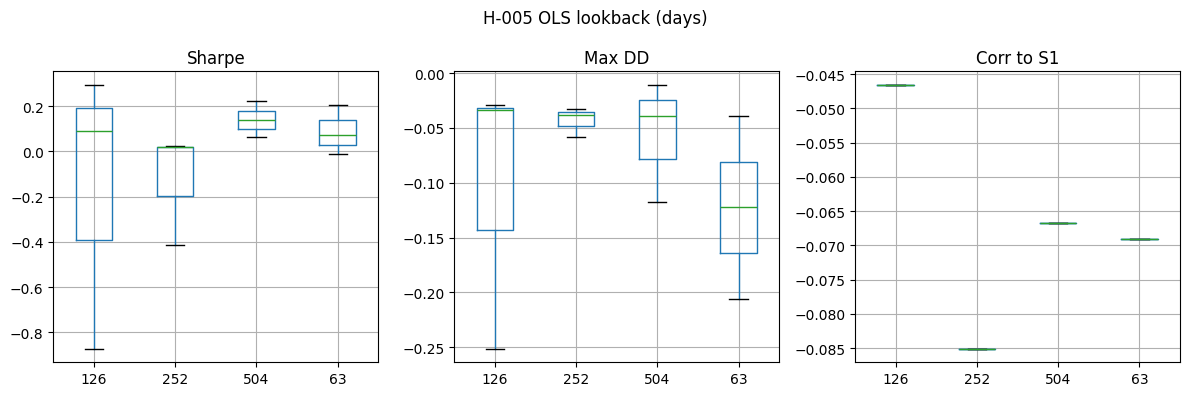

504


,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack
arm,,,,,,
126,0.089562,-0.034088,-0.046519,0.0,0.999725,0.966693
252,0.018430,-0.038635,-0.085148,0.0,0.773172,0.168787
504,0.138478,-0.039226,-0.066726,0.0,1.000000,0.999912
63,0.072324,-0.122229,-0.069066,0.0,0.997122,0.876407


In [6]:
HYP_ID = "H-005"
H005_SCREENS = {"ols": 0, "adf": 0, "entry_z": 0, "z_window": 0}
register_hypothesis_arms(HYP_ID, list(H005_SCREENS.keys()), overwrite=True)
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
configs_ols = {}
panels_ols = {}
for days in OLS_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=days, z_days=DAY_Z_WINDOW, adf_days=DAY_OLS_WINDOW)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    panels_ols[days] = p
    configs_ols[str(days)] = config_from_stack(
        stack, ols_window=lb["ols_window"], z_window=lb["z_window"], adf_window=lb["adf_window"]
    )

# fold_val_metrics expects one panel; score each arm on its own overlay.
rows = []
for days, p in panels_ols.items():
    cfg = {str(days): configs_ols[str(days)]}
    part = fold_val_metrics(p, folds, cfg, hyp_id=HYP_ID, s1_weekly=s1_weekly)
    rows.append(part)
fold_ols = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_ols, title="H-005 OLS lookback (days)")
plt.show()
print(median_sharpe_hint(fold_ols))
fold_ols.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1", "psr", "dsr_local", "dsr_stack"]].median()


In [7]:
OLS_WINDOW_STAR = 504   # TODO day units: 504 | 252 | 126 | 63
require_star("OLS_WINDOW_STAR", OLS_WINDOW_STAR)
stack["OLS_WINDOW_STAR"] = int(OLS_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote OLS_WINDOW_STAR", OLS_WINDOW_STAR)


wrote OLS_WINDOW_STAR 504


### 3.2 ADF window screen → `ADF_WINDOW_STAR`


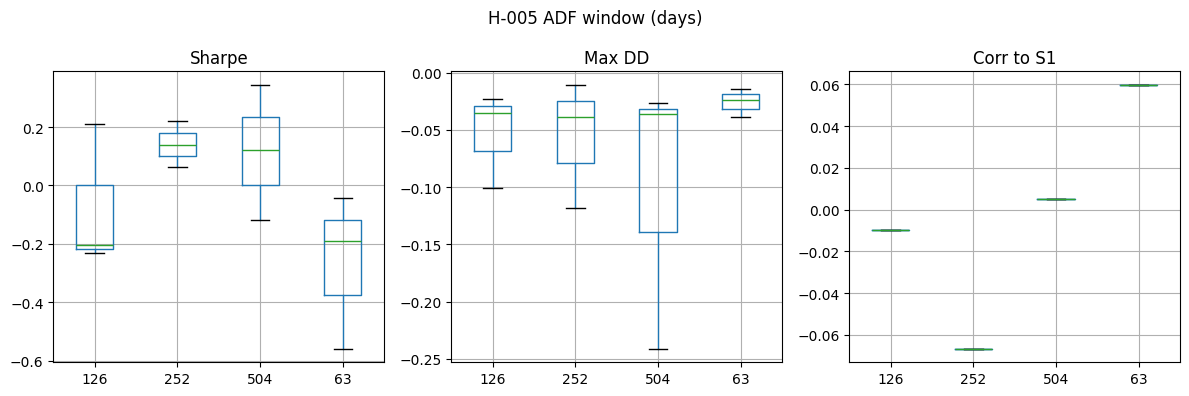

252


,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack
arm,,,,,,
126,-0.205247,-0.035556,-0.009688,0.0,3.386180e-15,0.000000e+00
252,0.138478,-0.039226,-0.066726,0.0,1.000000e+00,9.999117e-01
504,0.121440,-0.036604,0.004934,0.0,9.999997e-01,9.994823e-01
63,-0.190195,-0.023936,0.059843,0.0,7.855537e-08,8.646768e-09


In [8]:
HYP_ID = "H-005"
H005_SCREENS = {"ols": 0, "adf": 0, "entry_z": 0, "z_window": 0}
register_hypothesis_arms(HYP_ID, list(H005_SCREENS.keys()), overwrite=True)
require_star("OLS_WINDOW_STAR", stack.get("OLS_WINDOW_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
rows = []
for days in ADF_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=DAY_Z_WINDOW, adf_days=days)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    cfg = {str(days): config_from_stack(
        stack, ols_window=lb["ols_window"], z_window=lb["z_window"], adf_window=lb["adf_window"]
    )}
    rows.append(fold_val_metrics(p, folds, cfg, hyp_id=HYP_ID, s1_weekly=s1_weekly))
fold_adf = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_adf, title="H-005 ADF window (days)")
plt.show()
print(median_sharpe_hint(fold_adf))
fold_adf.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1", "psr", "dsr_local", "dsr_stack"]].median()


In [9]:
ADF_WINDOW_STAR = 252  # TODO day units: 504 | 252 | 126 | 63
require_star("ADF_WINDOW_STAR", ADF_WINDOW_STAR)
stack["ADF_WINDOW_STAR"] = int(ADF_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote ADF_WINDOW_STAR", ADF_WINDOW_STAR)


wrote ADF_WINDOW_STAR 252


### 3.3 Entry z screen → `ENTRY_Z_STAR`


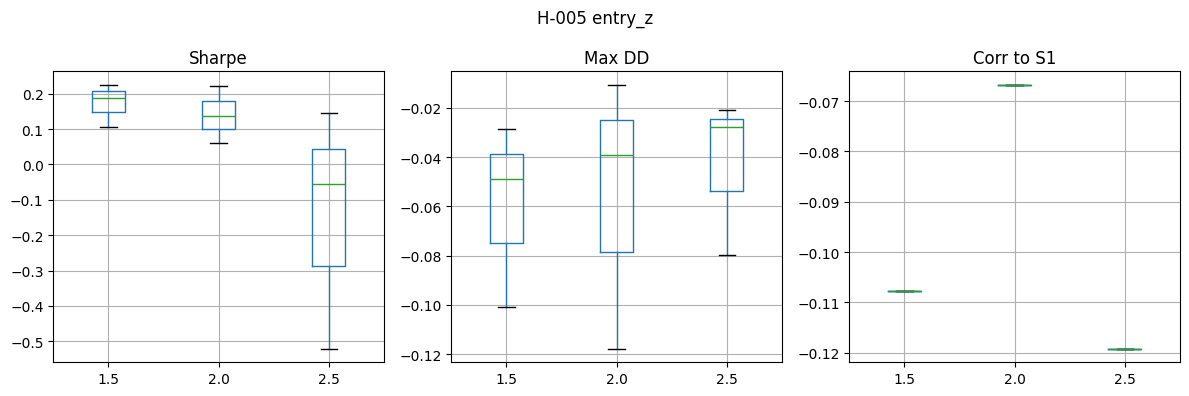

1.5


,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack
arm,,,,,,
1.5,0.188495,-0.048710,-0.107712,0.0,1.000000,1.000000
2.0,0.138478,-0.039226,-0.066726,0.0,0.999998,0.999889
2.5,-0.054099,-0.027832,-0.119249,0.0,0.000907,0.000023


In [10]:
HYP_ID = "H-005"
H005_SCREENS = {"ols": 0, "adf": 0, "entry_z": 0, "z_window": 0}
register_hypothesis_arms(HYP_ID, list(H005_SCREENS.keys()), overwrite=True)
require_star("ADF_WINDOW_STAR", stack.get("ADF_WINDOW_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
adf_days = int(stack["ADF_WINDOW_STAR"])
lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=DAY_Z_WINDOW, adf_days=adf_days)
panel_entry = overlay_ols_hedge(
    panel,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
configs_ez = {
    str(ez): config_from_stack(
        stack,
        entry_z=float(ez),
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        adf_window=lb["adf_window"],
    )
    for ez in ENTRY_Z_GRID
}
fold_ez = fold_val_metrics(panel_entry, folds, configs_ez, hyp_id=HYP_ID, s1_weekly=s1_weekly)
plot_fold_boxplots(fold_ez, title="H-005 entry_z")
plt.show()
print(median_sharpe_hint(fold_ez))
fold_ez.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1", "psr", "dsr_local", "dsr_stack"]].median()


In [11]:
ENTRY_Z_STAR = 1.5  # TODO: 1.5 | 2.0 | 2.5
require_star("ENTRY_Z_STAR", ENTRY_Z_STAR)
stack["ENTRY_Z_STAR"] = float(ENTRY_Z_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote ENTRY_Z_STAR", ENTRY_Z_STAR)


wrote ENTRY_Z_STAR 1.5


### 3.4 Z-window screen → `Z_WINDOW_STAR`


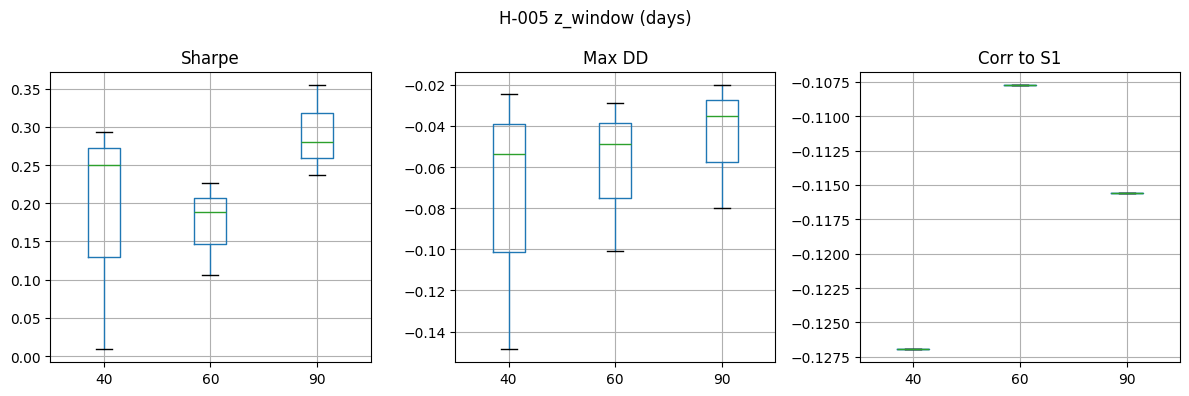

90


,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack
arm,,,,,,
40,0.249867,-0.053679,-0.126935,0.0,NaN,NaN
60,0.188495,-0.048710,-0.107712,0.0,NaN,NaN
90,0.280501,-0.035116,-0.115552,0.0,NaN,NaN


In [12]:
require_star("ENTRY_Z_STAR", stack.get("ENTRY_Z_STAR"))
ols_days = int(stack["OLS_WINDOW_STAR"])
adf_days = int(stack["ADF_WINDOW_STAR"])
rows = []
for days in Z_DAY_GRID:
    lb = lookbacks_for_bar(BAR, ols_days=ols_days, z_days=days, adf_days=adf_days)
    p = overlay_ols_hedge(
        panel,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    cfg = {str(days): config_from_stack(
        stack,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        adf_window=lb["adf_window"],
    )}
    rows.append(fold_val_metrics(p, folds, cfg, s1_weekly=s1_weekly))
fold_z = pd.concat(rows, ignore_index=True)
plot_fold_boxplots(fold_z, title="H-005 z_window (days)")
plt.show()
print(median_sharpe_hint(fold_z))
fold_z.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1", "psr", "dsr_local", "dsr_stack"]].median()


In [13]:
Z_WINDOW_STAR = 90  # TODO day units: 40 | 60 | 90
require_star("Z_WINDOW_STAR", Z_WINDOW_STAR)
stack["Z_WINDOW_STAR"] = int(Z_WINDOW_STAR)
save_star_stack(STAR_PATH, stack)
print("wrote Z_WINDOW_STAR", Z_WINDOW_STAR)


wrote Z_WINDOW_STAR 90


## 4. Sealed OOS once (full frozen stack)


In [14]:
stack = load_star_stack(STAR_PATH)
for key in ("BREAK_STAR", "OLS_WINDOW_STAR", "ADF_WINDOW_STAR", "ENTRY_Z_STAR", "Z_WINDOW_STAR"):
    require_star(key, stack.get(key))
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
oos_feat = overlay_ols_hedge(
    oos_panel,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
oos_cfg = config_from_stack(stack)
n_loc = n_trials_local(H005_SCREENS)
n_stk = n_trials_stack(HYP_ID, H005_SCREENS)
oos = run_s2_backtest(
    oos_feat, oos_cfg, s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print(oos.metrics)
arm = f"{stack['BREAK_STAR']}_ols{stack['OLS_WINDOW_STAR']}_adf{stack['ADF_WINDOW_STAR']}_ez{stack['ENTRY_Z_STAR']}_z{stack['Z_WINDOW_STAR']}"
write_tearsheet_pdf(
    tearsheet_path("H-005", arm), oos.returns, title=f"H-005 sealed OOS {arm}",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print("tearsheet", tearsheet_path("H-005", arm))


{'ann_sharpe': -0.5710032753538561, 'max_drawdown': -0.05156407172051025, 'n_days': 1173, 'psr': 0.0, 'dsr_local': 0.0, 'dsr_stack': 0.0, 'skew': -0.46597664813979484, 'excess_kurtosis': 10.758424084900746, 'n_trials_local': 4, 'n_trials_stack': 17, 'corr_to_s1': 0.11687522927545191}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-005_block_05_flat_10_ols504_adf252_ez1.5_z90.pdf


## 5. Notes for next hyp


H-006 Kalman β vs static OLS hedge is next, under frozen `BREAK_STAR`, `BOOK_STAR` and the
window STARs frozen here. Do not reopen these grids on sealed OOS.
